In [1]:
import math
import itertools
import mpmath as mp
import matplotlib.pyplot as plt

In [2]:
class DiffFunction:
    """ Eine Klasse fuer differenzierbare Funktionen 
    
    Attributes:
        f    (lambda(num) -> num): Die Funktion
        d1_f (lambda(num) -> num): Die 1. Ableitung der Funktion
    """
    def __init__(self, f, d1_f):
        self.f = f
        self.d1_f = d1_f
    
    def eval_at(self, x):
        """ Wertet die Funktion bei X aus
        
        Attributes:
            x (num): Wo die Funktion ausgewertet werden soll
        """
        return self.f(x)
        
    def first_der(self, x):
        """ Wertet die 1. Ableitung bei x aus
        
        Attributes:
            x (num): Wo die Ableitung ausgewertet werden soll
        """
        return self.d1_f(x)

In [3]:
def fixpunktiteration(f, n, x_0):
    """ Führt das Newton-Verfahren aus
    
        Args:
            f   (DiffFunction): Die Funktion, auf die das Verfahren anzuwenden ist
            n   (int): Anzahl der Iterationen
            x_0 (float): Startwert
    
        Returns:
            float: Die approximierte Nullstelle von f
    """

    x_i = x_0
    for i in range(n):
        fx_i = f.eval_at(x_i)
        d1_fx_i = f.first_der(x_i)
        x_ip1 = x_i - (fx_i/d1_fx_i)

        # !! DEBUG !!
        # Hab ich fuer Aufgabe 3 benutzt
        # print(f"x_{i+1} = {x_i} - ({fx_i}/{d1_fx_i}) = {x_ip1}")
        x_i = x_ip1
    return x_i

In [4]:
# Aufgabe 3
f3 = lambda x: x**3 - 2*x + 2
d1_f3 = lambda x: 3*(x**2) - 2

f = DiffFunction(f3, d1_f3)
fixpunktiteration(f, 10, 0)

0.0

In [5]:
# Aufgabe 4
f4 = lambda x: mp.tan(mp.pi/2*(mp.sin(2*x)**4)) - 10/7
d1_f4 = lambda x: 4*mp.pi*mp.cos(2*x)*(mp.sin(2 * x)**3)/(mp.cos(mp.pi/2*(mp.sin(2*x))**4)**2)

f = DiffFunction(f4, d1_f4)
x_0_list = [0.2, 0.35, 0.5, 0.65, 0.8]
n_list  = list(range(1, 15 + 1))


# Fuer jedes x_0, fuer jedes n, fuehre fixpunktiteration() aus
# Wir benutzen Iteratoren, denn wir brauchen die Werte nur in der einen Schleife unten 
x_final_iter = (
    [x_0, fixpunktiteration(f, n, x_0)] 
    for [x_0, n] in itertools.product(x_0_list, n_list)
)

In [6]:
mp.mp.dps = 50

# Berechne die Referenzwerte
x_ref_iter = ([x_0, mp.findroot(f4, x_0)] for x_0 in x_0_list)

# Bereite ein dict vor, in das wir die Fehler per 
results = dict([[x_0, []] for x_0 in x_0_list])

# Iteriere durch beide Iteratoren, bis die beiden leer sind.
x_ref   = next(x_ref_iter, None)
x_final = next(x_final_iter, None)


while x_ref != None and x_final != None:
    # Zieh die Werte aus den Tupeln
    [x_0r, x_valr] = x_ref
    [x_0f, x_valf] = x_final

    # Brauche erstmal alle aus x_final_iter mit einem gewissen x_0 auf,
    # denn es gibt fuer, jedes x_0, len(n_list) Eintraege in x_final_iter
    if x_0r != x_0f:
        x_ref = next(x_ref_iter, None)
    else:
        err = abs(x_valr - x_valf)
        ## !! DEBUG !!
        # print(f"{x_ref} - {x_f} = {err}")

        results[x_0r].append(err)
        x_final = next(x_final_iter, None)
    
print(next(x_final_iter, 'x_final_iter is empty!'))
print(next(x_ref_iter, 'x_ref_iter is empty!'))

x_final_iter is empty!
x_ref_iter is empty!


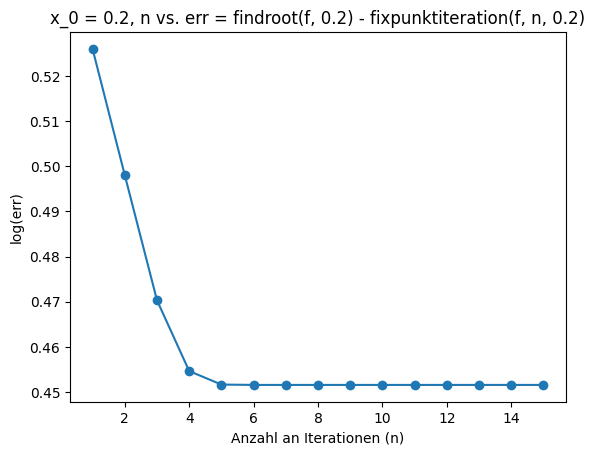

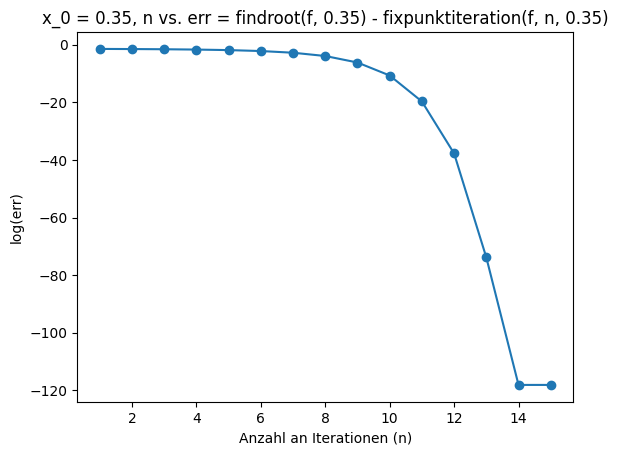

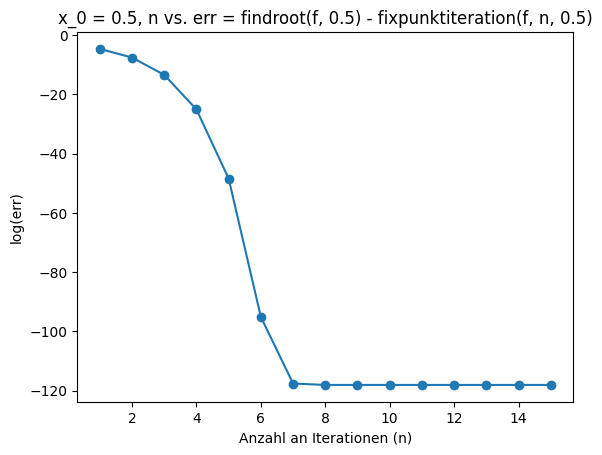

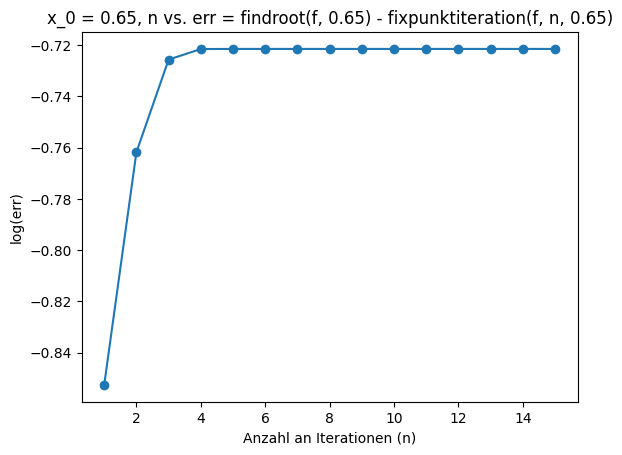

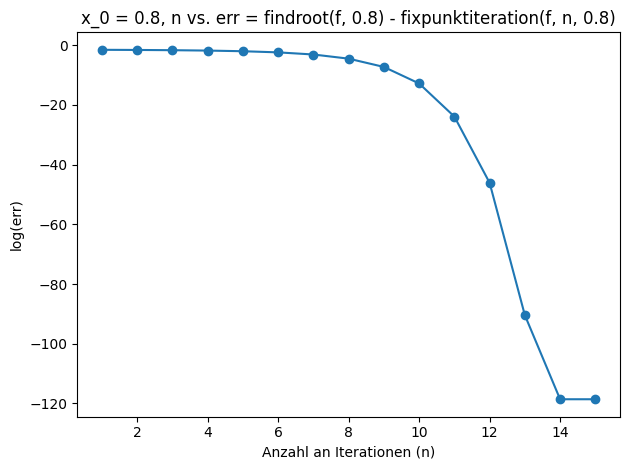

In [7]:
for x_0, errs in results.items():
    fig, plot1 = plt.subplots(1, 1) # Die Groesse hab ich von einem Beispiel
    y_vals = [mp.log(err) for err in errs]
    
    plot1.plot(n_list, y_vals, marker='o')
    plot1.set_title(f"x_0 = {x_0}, n vs. err = findroot(f, {x_0}) - fixpunktiteration(f, n, {x_0})")
    plot1.set_xlabel("Anzahl an Iterationen (n)")
    plot1.set_ylabel(f"log(err)")

plt.tight_layout()
plt.show()